<a href="https://colab.research.google.com/github/Neurotech-BCI/ErrP/blob/main/MI_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mne pyriemann

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 6.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import random
seed = 42
random.seed(seed)
np.random.seed(seed)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pathlib import Path
### Assumes you have a shortcut setup to outermost data/ dir under the neurotech BCI Project directory.
directory_path = Path('/content/drive/MyDrive/data/data/Mi Game')
data_files = [str(file_path.resolve()) for file_path in directory_path.rglob('*.edf')]
print(data_files)
print(len(data_files))

['/content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/Mi Game/26_03_06_nihitha_raw.edf', '/content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/Mi Game/03_09_26_mi_omer_0002_raw.edf', '/content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/Mi Game/260323_mi_andy_raw.edf']
3


In [5]:
event_id = {
  "left": 1,
  "right": 2,
}

In [26]:
import mne
import numpy as np

def load_raw_edf(edf_file_path):
  data = mne.io.read_raw_edf(edf_file_path, preload = True)
  print(data.info)
  print(f"Original channel names: {data.info.ch_names}")

  ### Reference to Left Ear channel, default is Pz ###
  data.set_eeg_reference(ref_channels=['EEG LE-Pz'])

  ### Standardize channel names ###
  rename_dict = {}
  for ch_name in data.ch_names:
      if '-Pz' in ch_name:
          rename_dict[ch_name] = ch_name.replace('-Pz', '')
      if ch_name == "Pz":
          rename_dict[ch_name] = "EEG Pz"
  data.rename_channels(rename_dict)
  print(f"Updated channel names: {data.info.ch_names}")

  ### Preprocess with bandpass ###
  data.filter(l_freq=8.0, h_freq=30.0, picks="eeg")

  ### Find events labeled in the Trigger column ###
  events = mne.find_events(data, stim_channel='Trigger', min_duration=0.0)
  print(f'Found {len(events)} events')
  print(f'Event IDs: {set(events[:, 2])}')
  print(f"Event Counts: {mne.count_events(events)}")
  ### Create epochs time locked to the event triggers ###
  epochs = mne.Epochs(
      data,
      events,
      event_id=event_id,
      tmin=0.0,      # Start 200 ms before event
      tmax=3.0,       # End 800 ms after event
      baseline=(0.0, 0.0),  # Baseline period for correction
      preload=True
  )
  channels = ['EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz']
  epochs = epochs.pick(channels)

  ### Plot epochs ###
  evokeds = [epochs[cond].average() for cond in list(event_id.keys())]
  mne.viz.plot_compare_evokeds(evokeds)

  ### Convert epochs and event labels to numpy ###
  samples = []
  labels = []
  for key in event_id.keys():
        datum = epochs[key].get_data()[:,:,:-1]
        samples.append(datum)
        labels.extend([key]*datum.shape[0])
  X = np.concatenate(samples, axis=0)
  y = np.array(labels)

  return X, y



Loading file #1/3
Extracting EDF parameters from /content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/Mi Game/26_03_06_nihitha_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 335399  =      0.000 ...  1117.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-06 13:48:08 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz', 'Trig

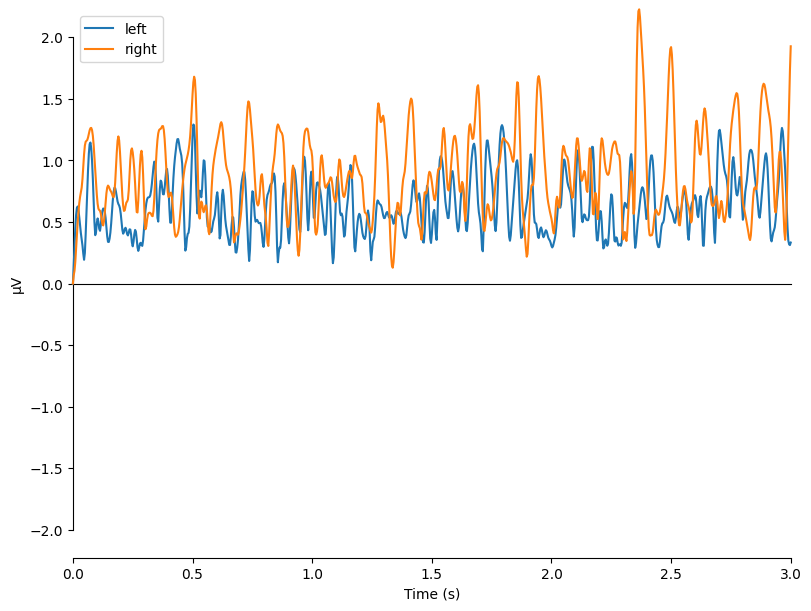

Loading file #2/3
Extracting EDF parameters from /content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/Mi Game/03_09_26_mi_omer_0002_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 291599  =      0.000 ...   971.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-09 12:05:04 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz', 

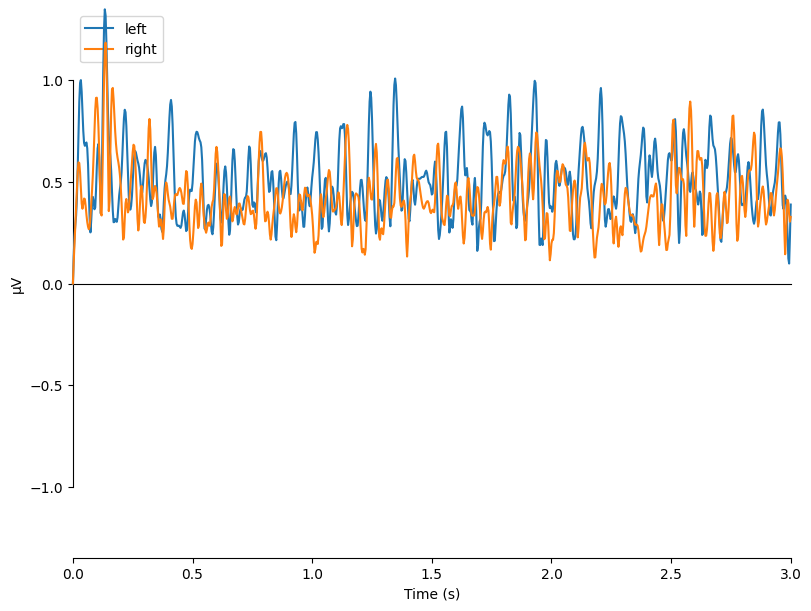

Loading file #3/3
Extracting EDF parameters from /content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/Mi Game/260323_mi_andy_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 326999  =      0.000 ...  1089.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-23 13:03:20 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz', 'Trigge

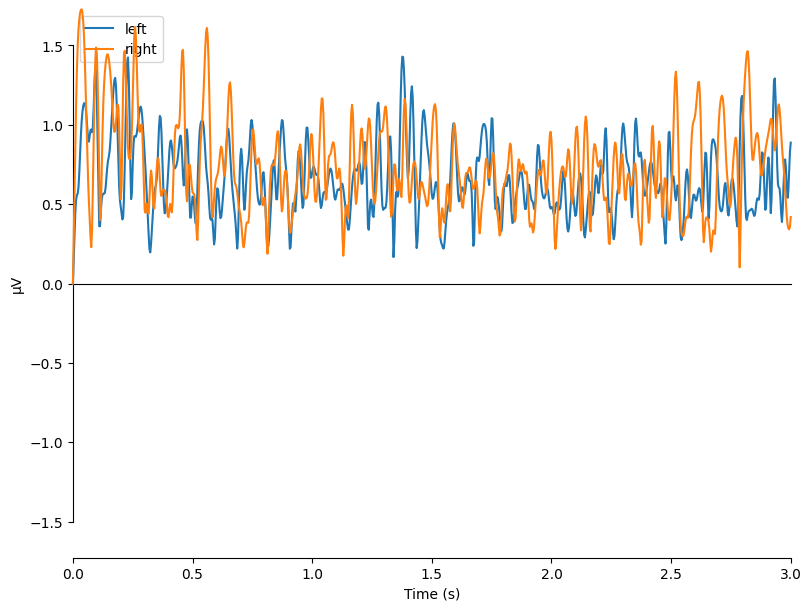

Shape of EEG data (num_trials, num_channels, epoch_len): (300, 7, 900)
Shape of labels array (num_trials,): (300,)
Shape of groups array (num_trials,): (300,)
Dataset label counts:
[['left' '150']
 ['right' '150']]
Dataset groups counts:
[[  0 100]
 [  1 100]
 [  2 100]]


In [27]:
import numpy as np
X = []
y = []
groups = []
total_len = len(data_files)
for i, data_file in enumerate(data_files):
  print(f"Loading file #{i+1}/{total_len}")
  datum, label = load_raw_edf(data_file)
  X.append(datum)
  y.append(label)
  groups.extend([i]*datum.shape[0])
X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)
groups = np.array(groups)
print(f"Shape of EEG data (num_trials, num_channels, epoch_len): {X.shape}")
print(f"Shape of labels array (num_trials,): {y.shape}")
print(f"Shape of groups array (num_trials,): {groups.shape}")
unique_labels, counts = np.unique(y,return_counts=True)
print("Dataset label counts:")
print(np.asarray((unique_labels, counts)).T)
unique_groups, counts = np.unique(groups,return_counts=True)
print("Dataset groups counts:")
print(np.asarray((unique_groups, counts)).T)

In [24]:
y = [0 if lab == 'left' else 1 for lab in y]
y = np.array(y)
unique_labels, counts = np.unique(y,return_counts=True)
print("Dataset label counts:")
print(np.asarray((unique_labels, counts)).T)

Dataset label counts:
[[  0 150]
 [  1 150]]


In [28]:
import numpy as np
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
### Within-Session Classification ###

def _make_classifier() -> Pipeline:
    return Pipeline([
        ("cov", Covariances(estimator="oas")),
        ("ts", TangentSpace(metric="riemann")),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis()),
    ])

# X: shape (num_samples, num_channels, window_len)
# y: shape (num_samples,)
# groups: shape (num_samples,) -> session id for each sample

session_scores = {}
all_session_means = []

unique_sessions = np.unique(groups)

for session_id in unique_sessions:
    session_mask = groups == session_id
    X_session = X[session_mask]
    y_session = y[session_mask]

    # Skip sessions that cannot support LOO classification
    if len(np.unique(y_session)) < 2:
        print(f"Session {session_id}: skipped (only one class present)")
        continue

    if len(y_session) < 2:
        print(f"Session {session_id}: skipped (fewer than 2 samples)")
        continue

    scores = cross_val_score(
        _make_classifier(),
        X_session,
        y_session,
        cv=LeaveOneOut(),
        scoring="accuracy",
        n_jobs=-1,
    )

    session_mean = scores.mean()
    session_std = scores.std()

    session_scores[session_id] = {
        "fold_scores": scores,
        "mean": session_mean,
        "std": session_std,
        "n_samples": len(y_session),
    }
    all_session_means.append(session_mean)

print("Results by session:")
for session_id in unique_sessions:
    if session_id not in session_scores:
        continue
    result = session_scores[session_id]
    print(
        f"  Session {session_id}: "
        f"accuracy={result['mean']:.3f} +/- {result['std']:.3f} "
        f"(n={result['n_samples']})"
    )

if all_session_means:
    print(f"\nAverage across sessions: {np.mean(all_session_means):.3f}")
    print(f"Std across sessions:     {np.std(all_session_means):.3f}")
else:
    print("\nNo valid sessions were evaluated.")

Results by session:
  Session 0: accuracy=0.520 +/- 0.500 (n=100)
  Session 1: accuracy=0.590 +/- 0.492 (n=100)
  Session 2: accuracy=0.840 +/- 0.367 (n=100)

Average across sessions: 0.650
Std across sessions:     0.137


In [21]:
import sys
import mne
import numpy as np
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, cross_val_score, LeaveOneOut
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

### Cross Session/Participant classification ###

def _make_classifier() -> Pipeline:
    return Pipeline([
        ("cov", Covariances(estimator="oas")),
        ("ts", TangentSpace(metric="riemann")),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis()),
    ])
scores = cross_val_score(_make_classifier(), X, y,cv=LeaveOneGroupOut(), groups=groups, scoring="accuracy")

print(f"Results:")
for pid, score in enumerate(scores):
    print(f"Fold #{pid}: accuracy={score:.3f}")
print(f"\n  Mean: {scores.mean():.3f} +/- {scores.std():.3f}")

Results:
Fold #0: accuracy=0.580
Fold #1: accuracy=0.520
Fold #2: accuracy=0.740

  Mean: 0.613 +/- 0.093
